In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Retail Sales Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to analyze retail sales data to uncover customer purchasing behaviour, sales trends, product performance and business insights using Python, Pandas, Matplotlib and Seaborn.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import sys
print(sys.executable)

c:\Users\nazzu\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("../dataset/customer_shopping.csv")

In [4]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
df.shape

(99457, 10)

In [5]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


In [7]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [5]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

In [5]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

ValueError: time data "16/05/2021" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [7]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

In [4]:
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    format="mixed",
    dayfirst=True
)

In [7]:
df.dtypes

invoice_no                   str
customer_id                  str
gender                       str
age                        int64
category                     str
quantity                   int64
price                    float64
payment_method               str
invoice_date      datetime64[us]
shopping_mall                str
dtype: object

In [8]:
df["age"].unique()

array([28, 21, 20, 66, 53, 49, 32, 69, 60, 36, 29, 67, 25, 24, 65, 42, 46,
       23, 27, 52, 44, 51, 50, 68, 43, 59, 54, 48, 40, 41, 19, 18, 22, 61,
       45, 64, 33, 63, 34, 47, 38, 57, 30, 26, 62, 39, 55, 56, 35, 31, 37,
       58])

In [9]:
df["quantity"].unique()

array([5, 3, 1, 4, 2])

In [10]:
df["price"].describe()

count    99457.000000
mean       689.256321
std        941.184567
min          5.230000
25%         45.450000
50%        203.300000
75%       1200.320000
max       5250.000000
Name: price, dtype: float64

In [11]:
df["gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [12]:
df["category"].unique()

<StringArray>
[       'Clothing',           'Shoes',           'Books',       'Cosmetics',
 'Food & Beverage',            'Toys',      'Technology',        'Souvenir']
Length: 8, dtype: str

In [13]:
df["payment_method"].unique()

<StringArray>
['Credit Card', 'Debit Card', 'Cash']
Length: 3, dtype: str

In [14]:
df["shopping_mall"].unique()

<StringArray>
[           'Kanyon',    'Forum Istanbul',         'Metrocity',
      'Metropol AVM',      'Istinye Park',  'Mall of Istanbul',
 'Emaar Square Mall',       'Cevahir AVM',    'Viaport Outlet',
      'Zorlu Center']
Length: 10, dtype: str

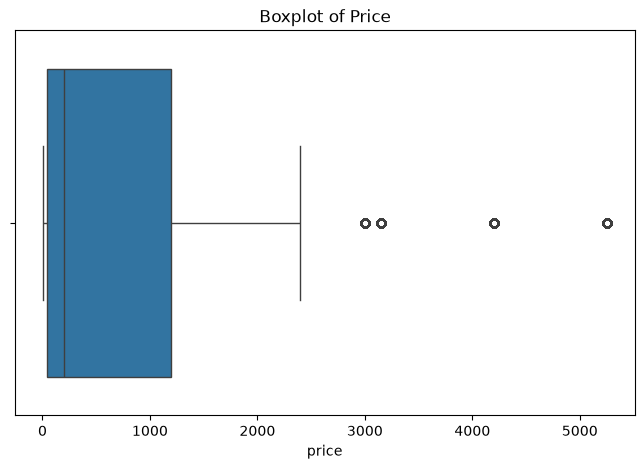

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Price")

plt.show()

In [7]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='str')

In [6]:
# Create Month and Quarter columns

df["Month"] = df["invoice_date"].dt.to_period("M")
df["Quarter"] = df["invoice_date"].dt.to_period("Q")

In [7]:
monthly_sales = df.groupby("Month")["price"].sum()

monthly_sales

Month
2021-01    2656422.78
2021-02    2358636.34
2021-03    2618434.14
2021-04    2558825.62
2021-05    2662369.93
2021-06    2547239.73
2021-07    2802468.58
2021-08    2632303.32
2021-09    2530305.88
2021-10    2782418.40
2021-11    2547152.35
2021-12    2619727.56
2022-01    2656149.96
2022-02    2318201.08
2022-03    2705190.76
2022-04    2543653.14
2022-05    2684556.89
2022-06    2613106.01
2022-07    2749554.99
2022-08    2638238.71
2022-09    2584908.39
2022-10    2755839.69
2022-11    2447988.76
2022-12    2675437.80
2023-01    2620053.89
2023-02    2558459.90
2023-03     683721.31
Freq: M, Name: price, dtype: float64

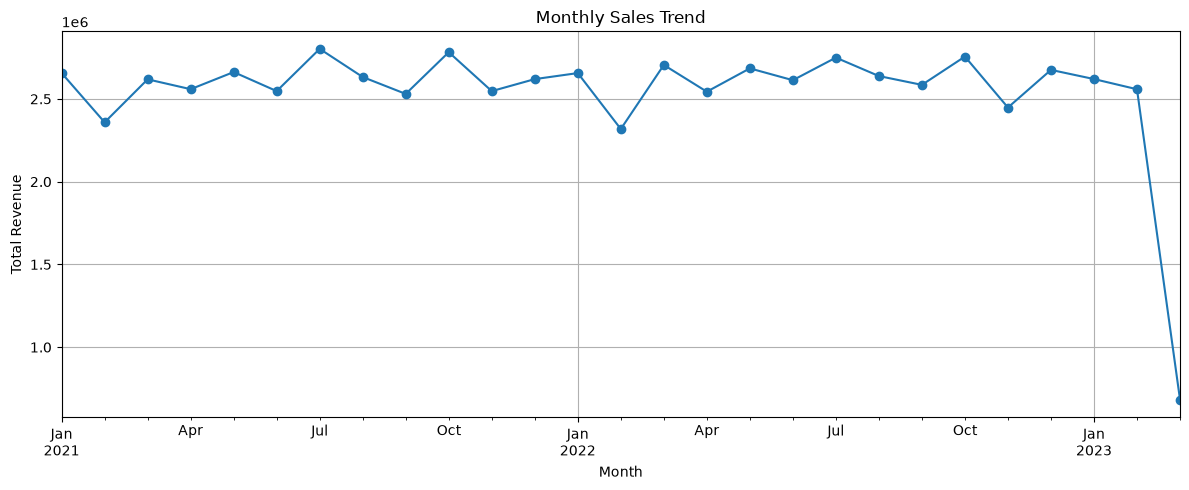

In [8]:
monthly_sales = df.groupby("Month")["price"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
quarterly_sales = df.groupby("Quarter")["price"].sum()

quarterly_sales

Quarter
2021Q1    7633493.26
2021Q2    7768435.28
2021Q3    7965077.78
2021Q4    7949298.31
2022Q1    7679541.80
2022Q2    7841316.04
2022Q3    7972702.09
2022Q4    7879266.25
2023Q1    5862235.10
Freq: Q-DEC, Name: price, dtype: float64

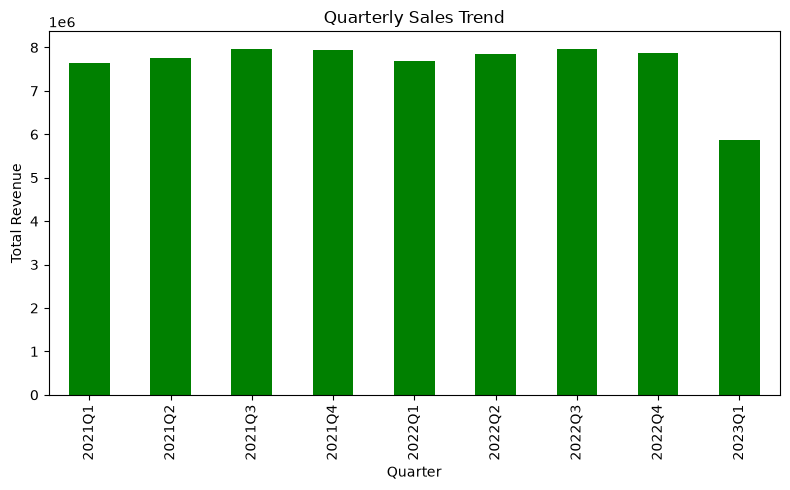

In [10]:
quarterly_sales = df.groupby("Quarter")["price"].sum()

plt.figure(figsize=(8,5))

quarterly_sales.plot(
    kind="bar",
    color="green"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")

plt.tight_layout()

plt.savefig(
    "../images/quarterly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

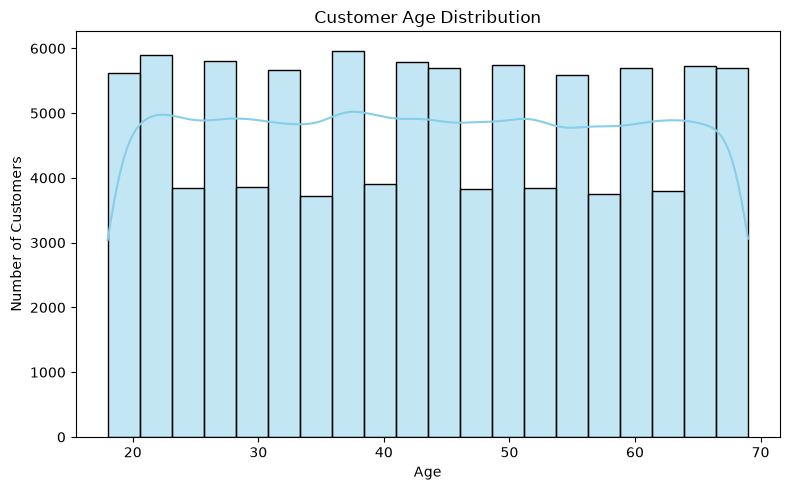

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True,
    color="skyblue"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

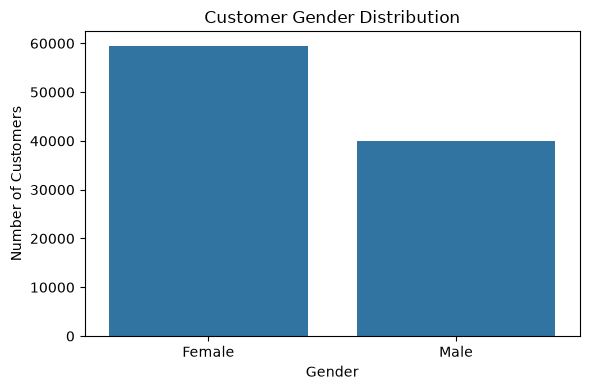

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/customer_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
category_sales = (
    df.groupby("category")["price"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Clothing           31075684.64
Shoes              18135336.89
Technology         15772050.00
Cosmetics           1848606.90
Toys                1086704.64
Food & Beverage      231568.71
Books                226977.30
Souvenir             174436.83
Name: price, dtype: float64

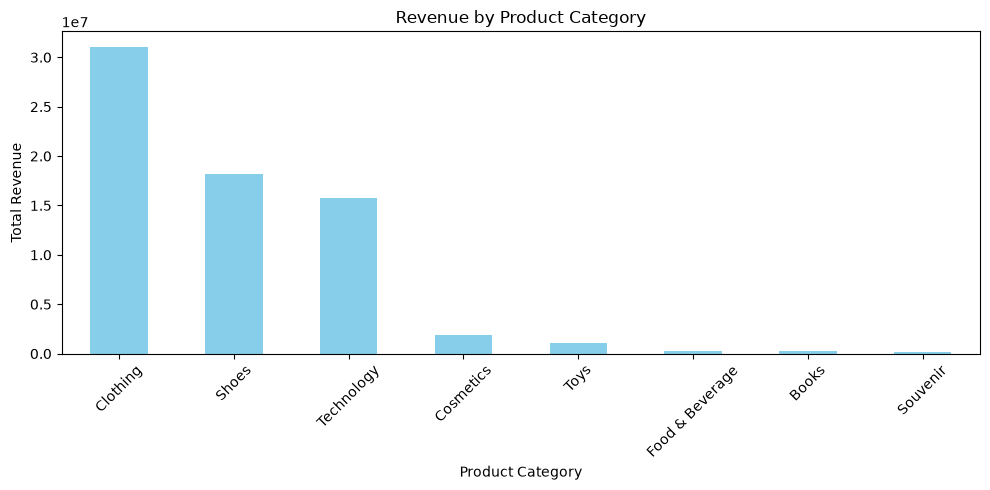

In [16]:
category_sales = (
    df.groupby("category")["price"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

category_sales.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/revenue_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
category_quantity = (
    df.groupby("category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

category_quantity

category
Clothing           103558
Cosmetics           45465
Food & Beverage     44277
Toys                30321
Shoes               30217
Technology          15021
Books               14982
Souvenir            14871
Name: quantity, dtype: int64

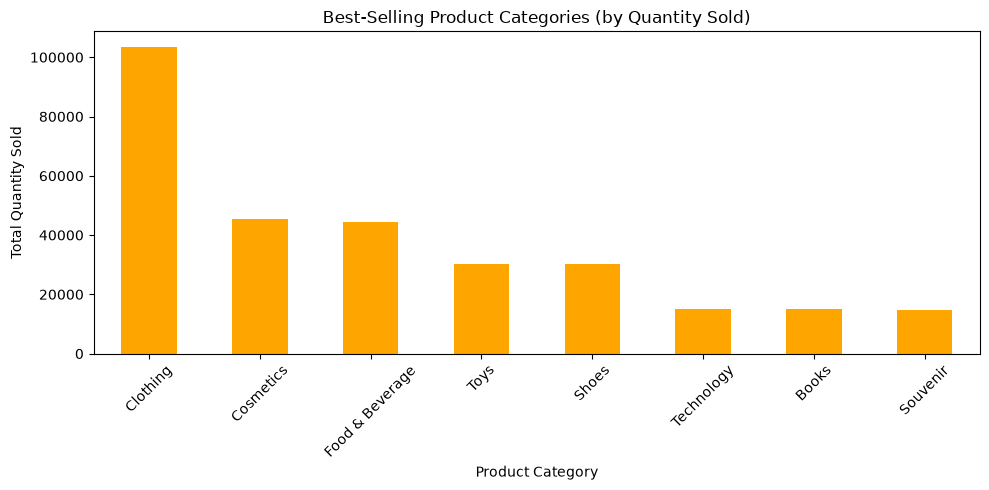

In [18]:
category_quantity = (
    df.groupby("category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

category_quantity.plot(
    kind="bar",
    color="orange"
)

plt.title("Best-Selling Product Categories (by Quantity Sold)")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/best_selling_product_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

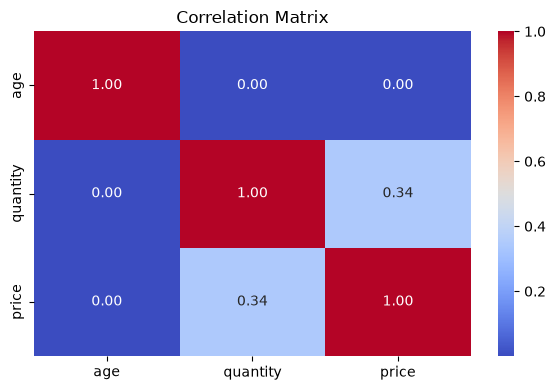

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["age", "quantity", "price"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

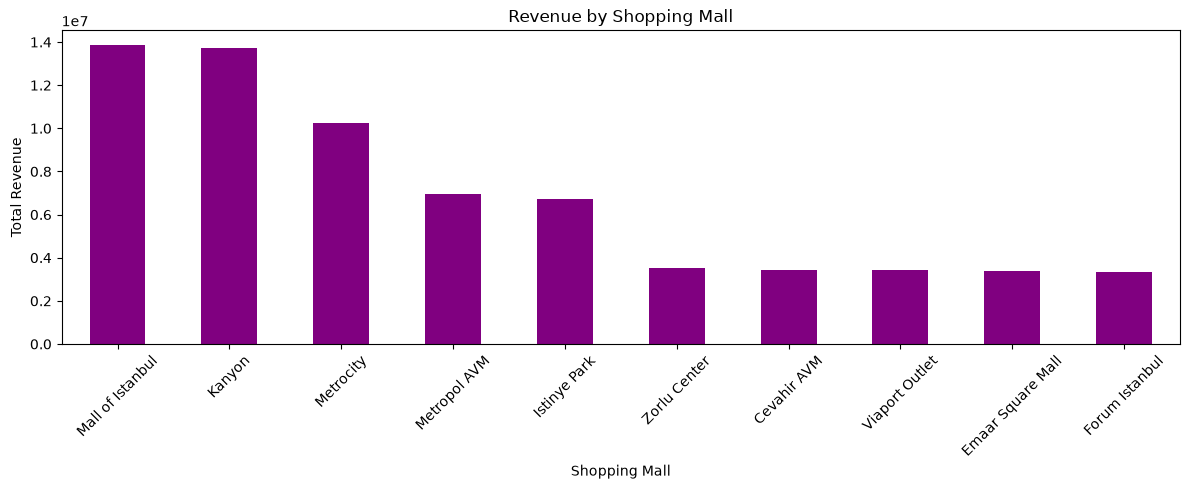

In [20]:
mall_sales = (
    df.groupby("shopping_mall")["price"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

mall_sales.plot(
    kind="bar",
    color="purple"
)

plt.title("Revenue by Shopping Mall")
plt.xlabel("Shopping Mall")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/revenue_by_shopping_mall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insights

### 1. Sales Trend Analysis
- Monthly sales remained relatively stable throughout 2021 and 2022, indicating consistent customer demand.
- The noticeable decline in the final month (March 2023) is likely due to incomplete transaction data rather than an actual decrease in sales.

### 2. Customer Demographics
- Female customers contributed a larger share of transactions compared to male customers.
- Customer purchases were distributed across all age groups, indicating that the business attracts a broad customer base rather than relying on a specific age segment.

### 3. Product Performance
- Clothing generated the highest revenue and also recorded the highest quantity sold, making it the strongest-performing product category.
- Shoes and Technology contributed significant revenue despite comparatively lower sales quantities, suggesting higher average selling prices.
- Categories such as Books, Souvenirs and Food & Beverage generated relatively lower revenue, indicating opportunities for targeted promotions.

### 4. Correlation Analysis
- Quantity and Price show a moderate positive correlation, suggesting that larger purchases generally result in higher transaction values.
- Customer Age has almost no correlation with purchase quantity or transaction value, indicating purchasing behaviour is largely independent of age.

### 5. Shopping Mall Performance
- Mall of Istanbul and Kanyon generated the highest revenue among all shopping malls.
- Lower-performing malls may require localized marketing campaigns or promotional strategies to increase customer traffic and sales.

# Conclusion

The exploratory data analysis reveals that the retail business maintains consistent sales performance across the observed period with only minor seasonal fluctuations. Clothing is the primary revenue driver, while Shoes and Technology also contribute significantly to total revenue. Female customers represent a larger portion of the customer base, and purchasing behaviour is distributed across different age groups. Revenue varies considerably across shopping malls, indicating location plays an important role in business performance. Overall, the analysis highlights several opportunities to improve sales through category-focused inventory planning and location-specific marketing strategies.

# Business Recommendations

1. Prioritize inventory planning for Clothing, Shoes and Technology categories to prevent stock shortages and maximize revenue.

2. Develop promotional campaigns for lower-performing product categories such as Books, Souvenirs and Food & Beverage to improve sales.

3. Analyze the operational strategies used by Mall of Istanbul and Kanyon and replicate successful practices across other shopping malls.

4. Implement location-specific marketing campaigns for malls with lower revenue to increase customer engagement and store traffic.

5. Continue monitoring monthly sales trends to identify seasonal demand patterns and support data-driven inventory and staffing decisions.